In [72]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
propinas = sns.load_dataset("tips")
propinas

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

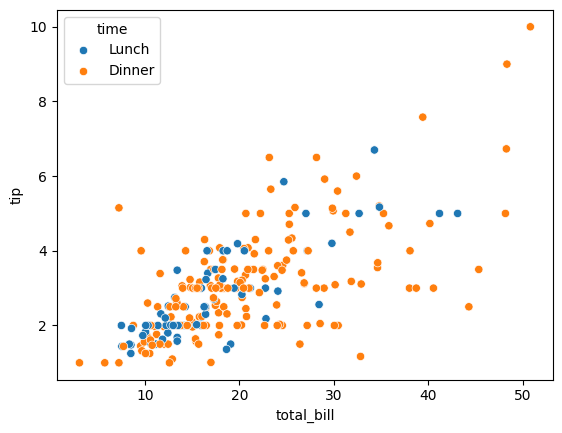

In [74]:
sns.scatterplot(x="total_bill", y="tip", data=propinas, hue="time")

<Axes: xlabel='total_bill', ylabel='tip'>

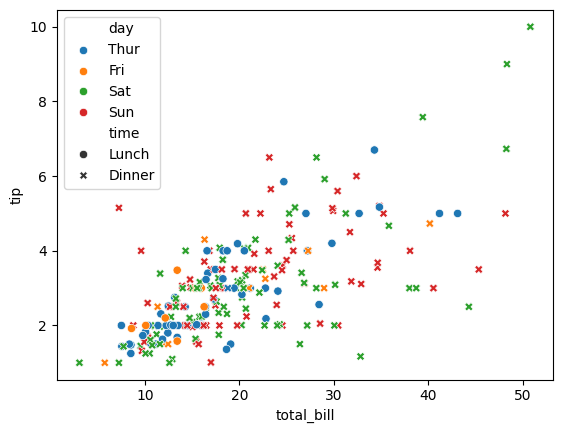

In [75]:
#asignar una variable 
sns.scatterplot(x="total_bill", y="tip", data=propinas, hue="day", style="time")

<Axes: xlabel='total_bill', ylabel='tip'>

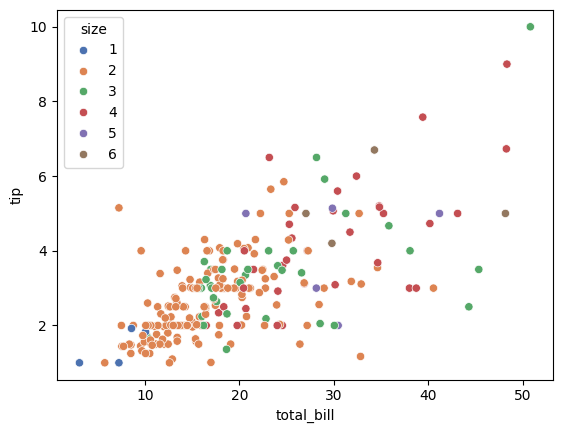

In [76]:
sns.scatterplot(x="total_bill", y="tip", data=propinas, hue="size", palette="deep")

In [77]:
#estrategias para visualizar datos unicos
propinas["size"].unique()

array([2, 3, 4, 1, 6, 5])

<Axes: xlabel='total_bill', ylabel='tip'>

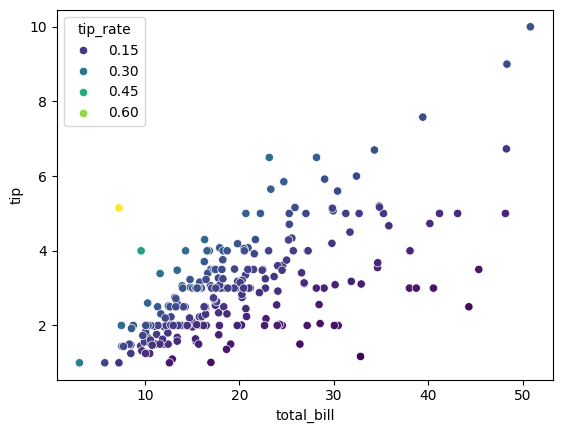

In [78]:
tip_rate = propinas.eval("tip / total_bill").rename("tip_rate")
sns.scatterplot(data=propinas, x="total_bill", y="tip", hue=tip_rate, palette="viridis")

In [79]:
#calcular la regresion lineal, correlacion, determinacion de personas
from sklearn.linear_model import LinearRegression

In [80]:
r = np.corrcoef(propinas["total_bill"], propinas["tip"])[0, 1]
print(f"Coeficiente de correlación: {r}")

Coeficiente de correlación: 0.6757341092113641


In [81]:
X = propinas["total_bill"].values.reshape(-1,1)
y = propinas["tip"].values

In [82]:
#correlacion de pearson
r=np.corrcoef(propinas["total_bill"], propinas["tip"])[0,1]
print("coeficiente de correlacion de Pearson:", r)

coeficiente de correlacion de Pearson: 0.6757341092113641


In [83]:
#regresion lineal simple
modelo = LinearRegression().fit(X,y)
r2 = modelo.score(X,y)
print("coeficiente de determinación R2:", r2)

coeficiente de determinación R2: 0.45661658635167657


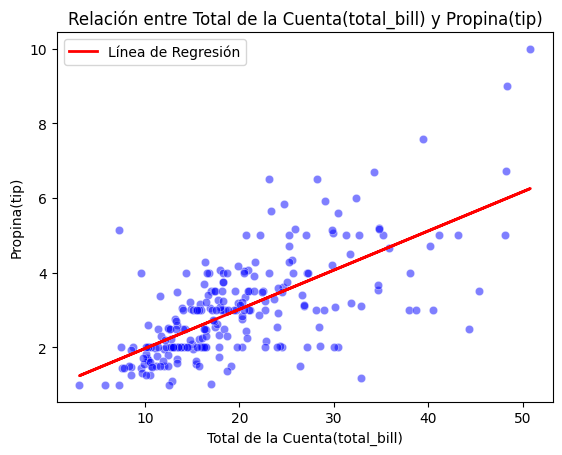

In [84]:
#graficar
sns.scatterplot(x=propinas["total_bill"], y=propinas["tip"],color="blue", alpha=0.5)
plt.plot(propinas["total_bill"], modelo.predict(X), color="red", linewidth=2, label="Línea de Regresión")
plt.xlabel("Total de la Cuenta(total_bill)")
plt.ylabel("Propina(tip)")
plt.title("Relación entre Total de la Cuenta(total_bill) y Propina(tip)")
plt.legend()
plt.show()

In [85]:
# coeficiente de la ecuacion
intercepo = modelo.intercept_
pendiente = modelo.coef_[0]
print("Ecuacion de prediccion:tip = {:.2f} + {:.2f} * total_bill".format(intercepo, pendiente))


Ecuacion de prediccion:tip = 0.92 + 0.11 * total_bill


In [86]:
#ejemplo de prediccion
tip_simulated = 200
prend_tip = modelo.predict([[tip_simulated]])
print(f"Prediccion de propina para una cuenta de ${tip_simulated}: ${prend_tip[0]:.2f}")

Prediccion de propina para una cuenta de $200: $21.93


pregunta 2: esat relacion es baja, ya que r2 el factor de determiancion es del  .4566, lo cual 